
# Surrogate Modeling of a Benzene–Toluene Distillation Column

**FOSSEE IIT Bombay — Screening Task 3**

**System:** Benzene–Toluene binary mixture, Peng–Robinson thermodynamic model
**Simulator:** DWSIM (3000 Latin Hypercube samples requested, generated via a scripted `Automation3` run)

**Objective:** train a surrogate model that predicts four column performance variables —
distillate purity ($x_D$), bottoms purity ($x_B$), condenser duty ($Q_C$), reboiler duty ($Q_R$) 
from seven operating conditions (feed temperature, feed pressure, feed composition, number of
stages, feed stage, reflux ratio, bottoms withdrawal rate), and to compare four ML approaches
(Polynomial Regression, Random Forest, XGBoost, ANN) per target, selecting the best one for each
based on accuracy, robustness, and physical consistency — not accuracy alone.

**Notebook structure**
1. Load & inspect data
2. Physical-validity screening of the raw simulation output
3. Exploratory data analysis
4. Feature engineering
5. Train/test split & preprocessing
6. Model training + hyperparameter search (4 models × 4 targets)
7. Performance comparison
8. Physical consistency audit (bounds + monotonicity)
9. Final model selection per target, with justification
10. Diagnostics for the winning models
11. Conclusion


In [3]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.stats import randint, uniform, spearmanr
import xgboost as xgb

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)


## 1. Load & inspect the DWSIM dataset

In [41]:

df_raw = pd.read_csv("dwsim_dataset.csv")
print("Shape:", df_raw.shape)
df_raw.head()


Shape: (2999, 12)


,feed_temperature,feed_pressure,feed_composition,number_of_stages,feed_stage,reflux_ratio,bottoms_flow,feed_flow,xD,xB,QC,QR
0,377.700368,175063.247139,0.382307,16,9,2.148462,13.905904,24.684562,0.849022,0.979447,1059.289507,1037.119728
1,377.383722,137013.173050,0.458665,20,16,1.523859,8.370331,30.034445,0.624398,0.970285,1764.625236,1690.659937
2,360.168729,168863.293728,0.691735,18,14,2.211731,11.178216,27.249536,0.999841,0.751268,1564.550926,1572.096936
3,369.711516,123875.159853,0.460231,18,17,1.534118,9.112146,27.486075,0.595159,0.811840,1508.035628,1496.548561
4,358.301553,187997.921707,0.530094,19,8,2.263669,9.686369,33.294107,0.747505,0.999780,2444.933572,2488.047635


In [5]:

df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2999 entries, 0 to 2998
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   feed_temperature  2999 non-null   float64
 1   feed_pressure     2999 non-null   float64
 2   feed_composition  2999 non-null   float64
 3   number_of_stages  2999 non-null   int64  
 4   feed_stage        2999 non-null   int64  
 5   reflux_ratio      2999 non-null   float64
 6   bottoms_flow      2999 non-null   float64
 7   feed_flow         2999 non-null   float64
 8   xD                2999 non-null   float64
 9   xB                2999 non-null   float64
 10  QC                2999 non-null   float64
 11  QR                2999 non-null   float64
dtypes: float64(10), int64(2)
memory usage: 281.3 KB


In [6]:

df_raw.describe().T


,count,mean,std,min,25%,50%,75%,max
feed_temperature,2999.0,365.003602,8.661008,350.005294,357.508930,365.000809,372.502472,379.997756
feed_pressure,2999.0,151981.085061,29258.120341,101343.481158,126660.514822,151955.864515,177329.618145,202639.274811
feed_composition,2999.0,0.499952,0.115478,0.300085,0.399991,0.499966,0.599835,0.699946
number_of_stages,2999.0,17.997999,1.999999,15.000000,16.000000,18.000000,20.000000,21.000000
feed_stage,2999.0,9.424475,4.790147,2.000000,5.000000,9.000000,13.000000,20.000000
reflux_ratio,2999.0,2.750041,0.721923,1.500117,2.125131,2.750631,3.375309,3.999955
bottoms_flow,2999.0,12.499364,2.598714,8.001565,10.250194,12.498513,14.749536,16.998966
feed_flow,2999.0,27.499223,4.331345,20.001228,23.748931,27.496724,31.249399,34.996333
xD,2999.0,0.833564,0.163190,0.411717,0.705613,0.885336,0.987415,0.999999
xB,2999.0,0.883570,0.142837,0.363652,0.809234,0.949537,0.998337,1.000000


In [7]:

print("Missing values per column:")
print(df_raw.isna().sum())
print("\nExact duplicate rows:", df_raw.duplicated().sum())


Missing values per column:
feed_temperature    0
feed_pressure       0
feed_composition    0
number_of_stages    0
feed_stage          0
reflux_ratio        0
bottoms_flow        0
feed_flow           0
xD                  0
xB                  0
QC                  0
QR                  0
dtype: int64

Exact duplicate rows: 0



The generator requested 3000 Latin-Hypercube cases; the CSV contains the rows that converged
successfully in DWSIM (cases that threw an exception — e.g. infeasible mass balance, non-convergence 
were skipped by the C# harness and never written). There are no missing values or duplicate rows in
what was written. However, "no NaNs" is not the same as "physically valid" ,DWSIM can converge to
a mathematically consistent but physically nonsensical operating point (e.g. a negative reboiler duty),
so the next section screens for that explicitly before any modeling happens.


## 2. Physical-validity screening of the raw simulation output


Before treating any row as ground truth, check that it obeys basic physics:

- $x_D, x_B \in [0, 1]$ — both are mole fractions.
- $Q_C, Q_R \ge 0$ — condenser duty (heat removed) and reboiler duty (heat supplied) are magnitudes;
  a negative value is not physically meaningful for either the actual physical process or how these
  columns are defined in this dataset, and signals a poorly-converged / boundary operating point.
- Bottoms withdrawal rate must not exceed feed flow ($B \le F$), by mass-balance.

Screening the *data* for physical validity up front, and later screening *predictions* the same way,
closes that gap at both ends of the pipeline.


In [8]:

violations = pd.DataFrame({
    "xD_out_of_bounds": [((df_raw['xD'] < 0) | (df_raw['xD'] > 1)).sum()],
    "xB_out_of_bounds": [((df_raw['xB'] < 0) | (df_raw['xB'] > 1)).sum()],
    "QC_negative": [(df_raw['QC'] < 0).sum()],
    "QR_negative": [(df_raw['QR'] < 0).sum()],
    "bottoms_exceeds_feed": [(df_raw['bottoms_flow'] > df_raw['feed_flow']).sum()],
})
violations


,xD_out_of_bounds,xB_out_of_bounds,QC_negative,QR_negative,bottoms_exceeds_feed
0,0,0,0,11,0


In [9]:

neg_qr = df_raw[df_raw['QR'] < 0]
print(f"{len(neg_qr)} rows have a negative reboiler duty (physically invalid).")
neg_qr[['reflux_ratio', 'bottoms_flow', 'feed_flow', 'number_of_stages', 'xB', 'QC', 'QR']]


11 rows have a negative reboiler duty (physically invalid).


,reflux_ratio,bottoms_flow,feed_flow,number_of_stages,xB,QC,QR
100,2.686640,15.940114,21.546779,16,0.554475,626.757626,-82.173044
171,3.459138,15.654751,20.038657,15,0.416236,592.861896,-72.960685
249,2.419638,15.658758,22.392939,21,0.496629,699.365449,-37.749326
471,2.171344,16.219888,21.563107,17,0.541469,514.376470,-196.215892
1129,1.601667,14.875666,24.177446,16,0.628585,750.409534,-53.343257
1133,2.051803,15.062092,23.344107,20,0.628488,770.745690,-6.437750
1187,2.278077,15.726784,23.375534,21,0.499811,759.969342,-16.169600
1558,1.653442,16.116680,22.983829,19,0.737268,579.215764,-181.745270
2026,1.755368,15.053112,20.502685,19,0.411547,455.170870,-207.132106
2484,1.608676,16.274923,24.818043,15,0.742218,707.464519,-63.673400



All 11 physically-invalid rows share a pattern: a high bottoms withdrawal rate relative to feed
flow combined with a low reflux ratio. That combination pushes the column towards its feasible
operating boundary (not enough internal reflux to sustain the specified bottoms draw), and DWSIM's
solver converges to a formally-balanced but physically-inconsistent duty split. These points would
teach a surrogate model that negative reboiler duties are a valid output — which is exactly the kind
of error a purely accuracy-driven model selection can miss. They are dropped rather than clipped,
since clipping would fabricate a value DWSIM never actually predicted.


In [10]:

df = df_raw[df_raw['QR'] >= 0].reset_index(drop=True)
print(f"Rows before screening: {len(df_raw)}  |  after screening: {len(df)}  "
      f"|  dropped: {len(df_raw) - len(df)} ({(len(df_raw)-len(df))/len(df_raw)*100:.2f}%)")


Rows before screening: 2999  |  after screening: 2988  |  dropped: 11 (0.37%)


## 3. Exploratory data analysis

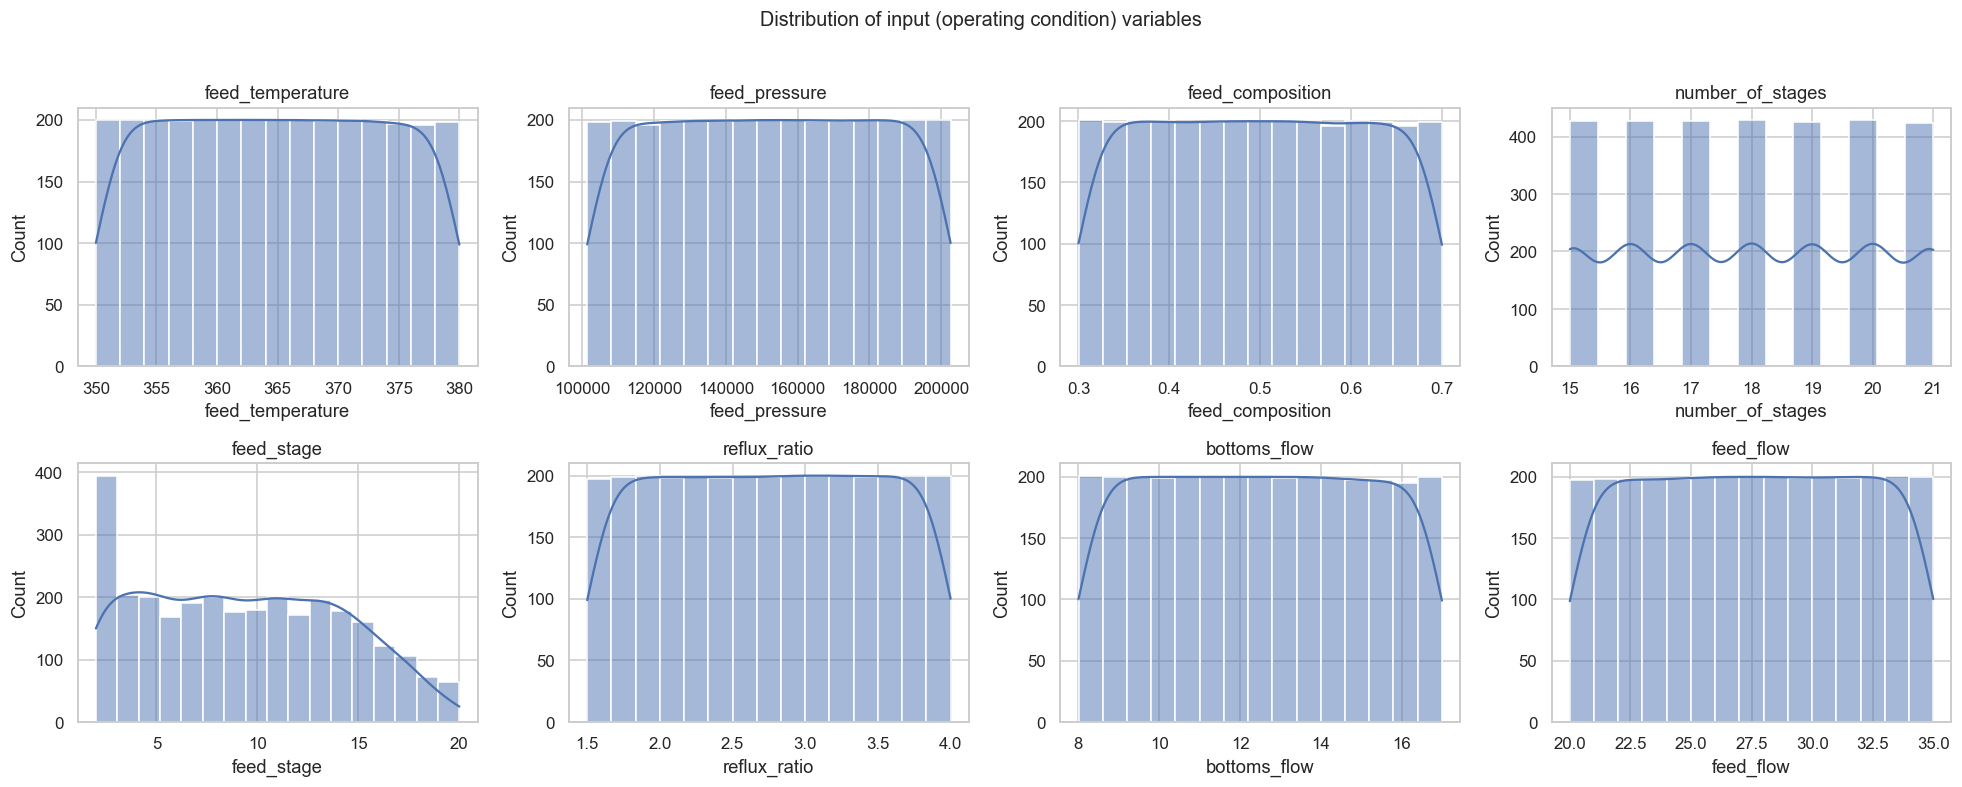

In [11]:

input_cols = ['feed_temperature', 'feed_pressure', 'feed_composition', 'number_of_stages',
              'feed_stage', 'reflux_ratio', 'bottoms_flow', 'feed_flow']
target_cols = ['xD', 'xB', 'QC', 'QR']

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for ax, col in zip(axes.flat, input_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="#4C72B0")
    ax.set_title(col)
plt.suptitle("Distribution of input (operating condition) variables", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


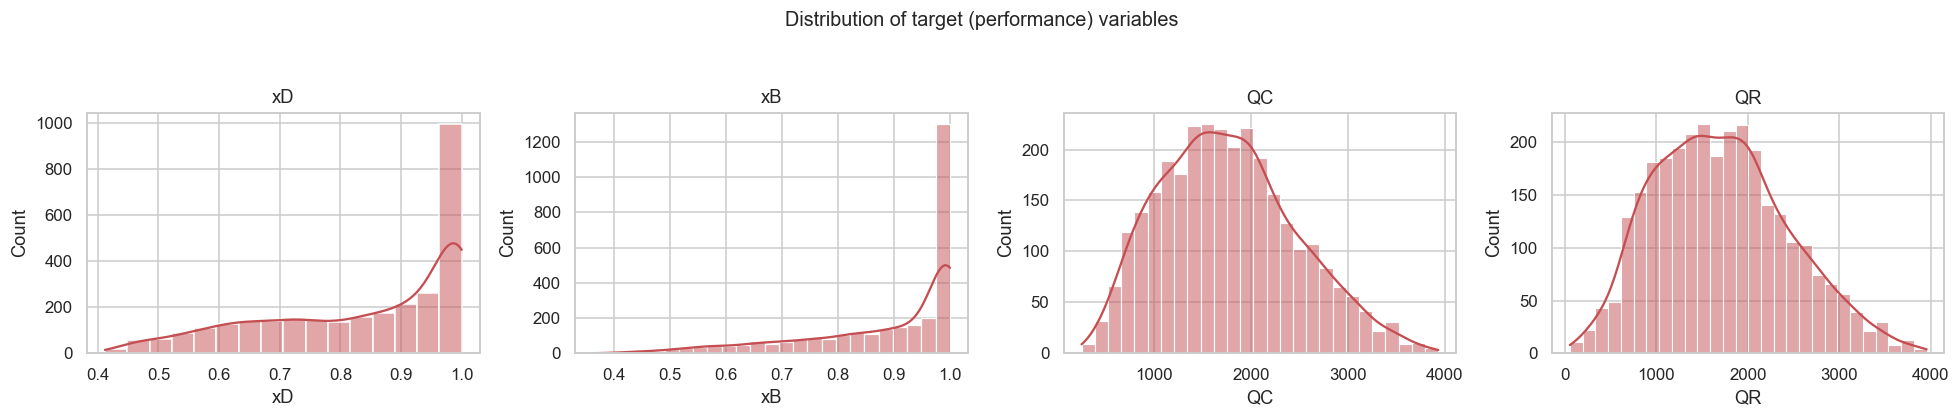

In [12]:

fig, axes = plt.subplots(1, 4, figsize=(18, 3.6))
for ax, col in zip(axes.flat, target_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="#C44E52")
    ax.set_title(col)
plt.suptitle("Distribution of target (performance) variables", y=1.05, fontsize=13)
plt.tight_layout()
plt.show()



$x_D$ and $x_B$ are both left-skewed toward high purity — most Latin-Hypercube samples land in
column configurations (enough stages, enough reflux) that achieve good separation, with a tail of
harder cases near the sampled parameter extremes (few stages, low reflux, extreme feed composition).
$Q_C$ and $Q_R$ are right-skewed and strongly linked to feed flow and reflux ratio (checked below).


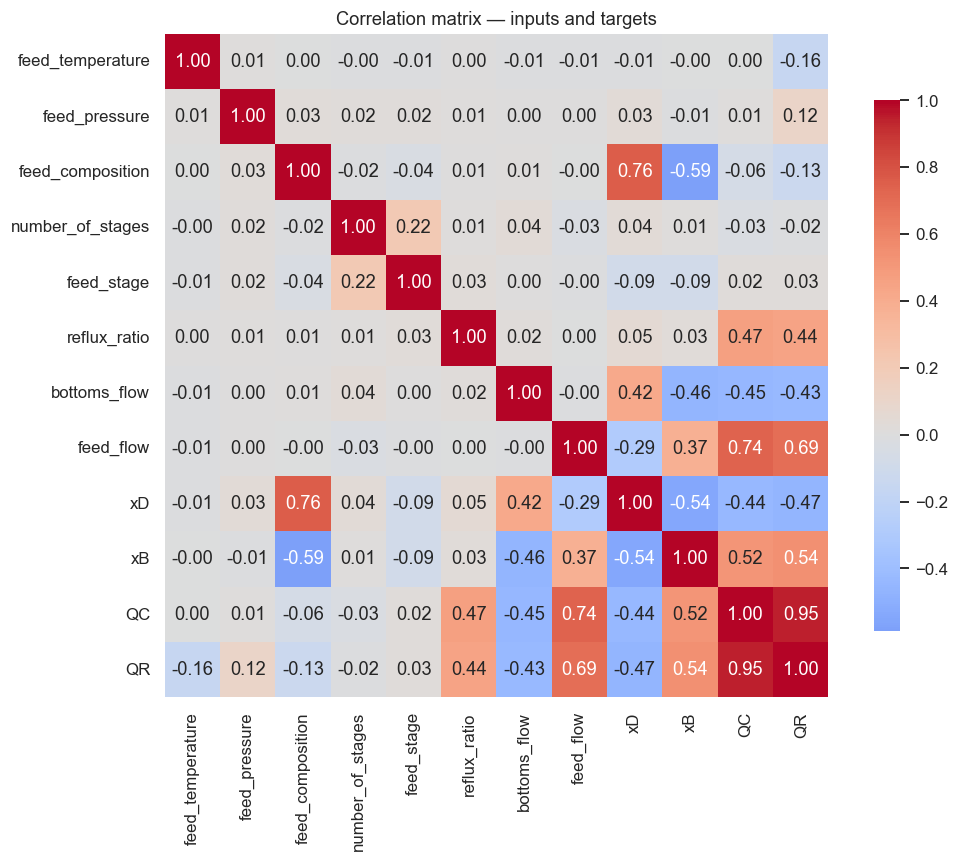

In [13]:

plt.figure(figsize=(10, 8))
corr = df[input_cols + target_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True,
            cbar_kws={"shrink": 0.8})
plt.title("Correlation matrix — inputs and targets")
plt.tight_layout()
plt.show()


**Correlation matrix — key observations**

- `feed_composition` is the strongest driver of purity: +0.76 with xD, -0.59 with xB —
  more benzene in the feed pushes distillate purity up but bottoms purity down (a real
  physical trade-off, not two independent effects).
- `QC` and `QR` correlate at +0.95 — expected, since both come from the same overall
  column energy balance.
- `feed_flow` and `reflux_ratio` are the main drivers of both duties (+0.74/+0.69 and
  +0.47/+0.44 with QC/QR respectively) — more material and more internal reflux traffic
  both require more heating/cooling.
- `reflux_ratio` shows only a weak linear correlation with xD (+0.05) despite being a
  physically important driver — because the true relationship is a saturating curve
  (diminishing returns near xD≈1), not a straight line. Correlation only captures linear
  relationships, so this one is under-represented here and is checked properly later via
  partial dependence (Section 8).
- Takeaway: correlation is a useful first-pass sanity check, not the final word on feature
  importance — non-linear effects need other tools to surface.

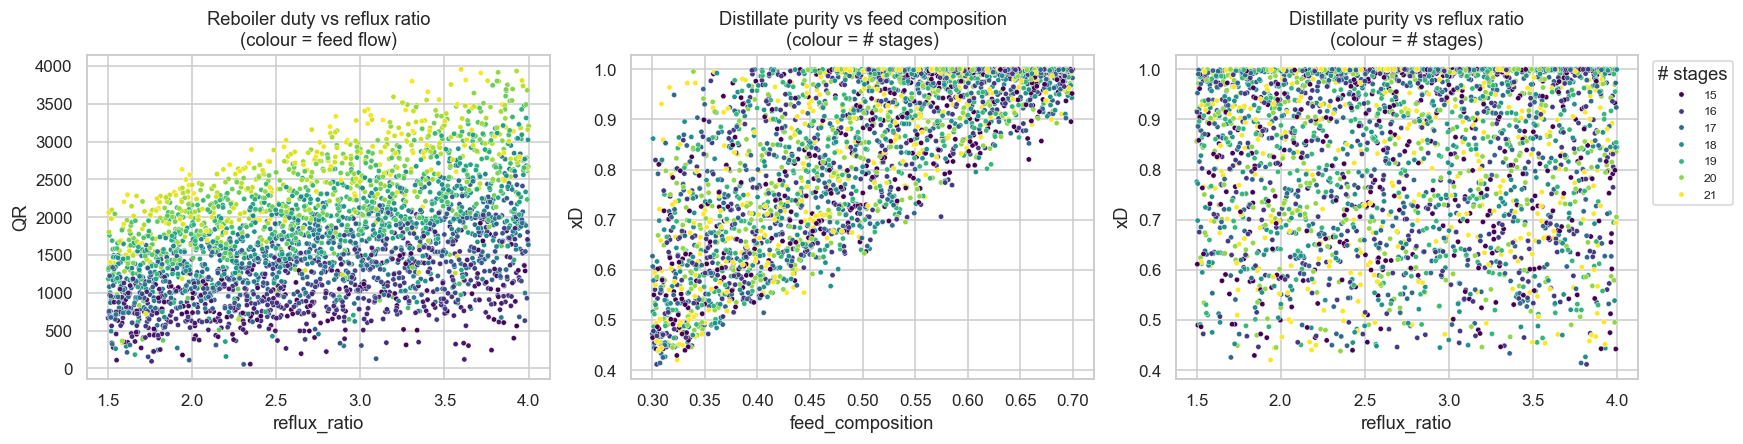

In [14]:

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

sns.scatterplot(data=df, x='reflux_ratio', y='QR', hue='feed_flow', palette='viridis',
                 s=12, ax=axes[0], legend=False)
axes[0].set_title("Reboiler duty vs reflux ratio\n(colour = feed flow)")

sns.scatterplot(data=df, x='feed_composition', y='xD', hue='number_of_stages', palette='viridis',
                 s=12, ax=axes[1], legend=False)
axes[1].set_title("Distillate purity vs feed composition\n(colour = # stages)")

sns.scatterplot(data=df, x='reflux_ratio', y='xD', hue='number_of_stages', palette='viridis',
                 s=12, ax=axes[2])
axes[2].set_title("Distillate purity vs reflux ratio\n(colour = # stages)")
axes[2].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, title='# stages')

plt.tight_layout()
plt.show()



These three relationships are useful physical sanity checks to keep in mind for later, when
predictions from the trained models are audited:

- $Q_R$ rises with reflux ratio and with feed flow — consistent with the reboiler having to vaporize
  more internal traffic.
- $x_D$ generally improves with more stages and is not simply monotonic in feed composition alone,
  it depends on the interaction between composition and how much separation duty the column has
  (stages, reflux) to work with.
- $x_D$ increases with reflux ratio and saturates near 1.0 for well-staged columns , the classic
  diminishing-returns shape of a McCabe–Thiele-type relationship.

A model that reproduces a *flat or negative* trend of $Q_R$ against reflux ratio, or of $x_D$ against
reflux ratio, would be learning noise rather than the underlying physics, even if its point-wise
$R^2$ looks acceptable. This gets checked explicitly in Section 8.


## 4. Feature engineering


Beyond the seven required operating conditions, a few physically-derived features are added. Each is
computed only from raw inputs (no leakage from targets):

| Feature | Definition | Physical rationale |
|---|---|---|
| `distillate_flow` | `feed_flow - bottoms_flow` | Overall mass balance ($D = F - B$); the column's distillate draw, not present as a raw input but fully determined by two of them. |
| `feed_stage_ratio` | `feed_stage / number_of_stages` | Where the feed enters *relative* to column height matters more than the absolute stage number — e.g. feed stage 9 means something different in a 15-stage vs a 21-stage column. |
| `bottoms_to_feed_ratio` | `bottoms_flow / feed_flow` | A dimensionless split ratio; captures how "aggressive" the bottoms draw is relative to feed, which is exactly the ratio implicated in the physically-invalid rows dropped in Section 2. |

`feed_composition` is the benzene mole fraction; toluene mole fraction is `1 - feed_composition` and
therefore carries no extra information, so it is not added separately (avoiding a redundant, perfectly
collinear feature).


In [15]:

df['distillate_flow'] = df['feed_flow'] - df['bottoms_flow']
df['feed_stage_ratio'] = df['feed_stage'] / df['number_of_stages']
df['bottoms_to_feed_ratio'] = df['bottoms_flow'] / df['feed_flow']

feature_cols = input_cols + ['distillate_flow', 'feed_stage_ratio', 'bottoms_to_feed_ratio']
print("Final feature set:", feature_cols)
df[feature_cols + target_cols].head()


Final feature set: ['feed_temperature', 'feed_pressure', 'feed_composition', 'number_of_stages', 'feed_stage', 'reflux_ratio', 'bottoms_flow', 'feed_flow', 'distillate_flow', 'feed_stage_ratio', 'bottoms_to_feed_ratio']


,feed_temperature,feed_pressure,feed_composition,number_of_stages,feed_stage,reflux_ratio,bottoms_flow,feed_flow,distillate_flow,feed_stage_ratio,bottoms_to_feed_ratio,xD,xB,QC,QR
0,377.700368,175063.247139,0.382307,16,9,2.148462,13.905904,24.684562,10.778659,0.562500,0.563344,0.849022,0.979447,1059.289507,1037.119728
1,377.383722,137013.173050,0.458665,20,16,1.523859,8.370331,30.034445,21.664114,0.800000,0.278691,0.624398,0.970285,1764.625236,1690.659937
2,360.168729,168863.293728,0.691735,18,14,2.211731,11.178216,27.249536,16.071320,0.777778,0.410217,0.999841,0.751268,1564.550926,1572.096936
3,369.711516,123875.159853,0.460231,18,17,1.534118,9.112146,27.486075,18.373929,0.944444,0.331519,0.595159,0.811840,1508.035628,1496.548561
4,358.301553,187997.921707,0.530094,19,8,2.263669,9.686369,33.294107,23.607738,0.421053,0.290933,0.747505,0.999780,2444.933572,2488.047635


## 5. Train/test split

In [17]:
X = df[feature_cols].copy()
y = df[target_cols].copy()


X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")


Train: 2090 | Val: 449 | Test: 449



Each target is modeled with its own independent regressor per algorithm (rather than one
multi-output model), since $x_D$/$x_B$ and $Q_C$/$Q_R$ live on very different scales and, more
importantly, may genuinely favour different algorithms — which is exactly what the task asks to be
investigated. Preprocessing (scaling / polynomial expansion) is done **inside** an sklearn
`Pipeline` fit only on the training fold in every case, so there is no leakage into cross-validation
or the test set.


## 6. Model training and hyperparameter search


Four model families are compared for every target:

1. **Polynomial Regression (Ridge-regularised)** — degree and regularisation strength are the only
   hyperparameters, and the space is small enough to search exhaustively, so **`GridSearchCV`** is
   used here.
2. **Random Forest** — several interacting hyperparameters (depth, leaf size, feature subsampling,
   number of trees) with a large combinatorial space; an exhaustive grid would be wasteful, so
   **`RandomizedSearchCV`** is used.
3. **XGBoost** — similarly high-dimensional hyperparameter space (learning rate, depth, subsampling,
   column sampling, n_estimators); **`RandomizedSearchCV`** again.
4. **ANN (`MLPRegressor`)** — architecture + regularisation + learning rate together form a large,
   non-convex-to-search space where grid search would be prohibitively expensive;
   **`RandomizedSearchCV`** with early stopping to control training time and reduce overfitting risk.

All searches use 3-fold CV on the training set only, scored on $R^2$.


In [18]:

def make_poly_pipeline():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(include_bias=False)),
        ("ridge", Ridge(random_state=RANDOM_STATE)),
    ])

def make_mlp_pipeline():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPRegressor(max_iter=1500, random_state=RANDOM_STATE,
                              early_stopping=True, n_iter_no_change=15, validation_fraction=0.15)),
    ])

MODEL_CONFIGS = {
    "Polynomial (Ridge)": dict(
        estimator=make_poly_pipeline(),
        param_grid={"poly__degree": [1, 2, 3], "ridge__alpha": [0.01, 0.1, 1.0, 10.0, 50.0]},
        search="grid",
    ),
    "Random Forest": dict(
        estimator=RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        param_grid={
            "n_estimators": randint(150, 450),
            "max_depth": randint(5, 22),
            "min_samples_leaf": randint(1, 6),
            "max_features": ["sqrt", 0.6, 1.0],
        },
        search="random", n_iter=12,
    ),
    "XGBoost": dict(
        estimator=xgb.XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, objective="reg:squarederror"),
        param_grid={
            "n_estimators": randint(200, 500),
            "max_depth": randint(3, 7),
            "learning_rate": uniform(0.02, 0.25),
            "subsample": uniform(0.7, 0.3),
            "colsample_bytree": uniform(0.7, 0.3),
        },
        search="random", n_iter=15,
    ),
    "ANN (MLP)": dict(
        estimator=make_mlp_pipeline(),
        param_grid={
            "mlp__hidden_layer_sizes": [(32,), (64,), (64, 32), (128, 64), (64, 64, 32)],
            "mlp__alpha": uniform(0.0001, 0.01),
            "mlp__learning_rate_init": uniform(0.0005, 0.006),
        },
        search="random", n_iter=8,
    ),
}
print("Model families:", list(MODEL_CONFIGS.keys()))


Model families: ['Polynomial (Ridge)', 'Random Forest', 'XGBoost', 'ANN (MLP)']


In [19]:

import time

cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
fitted_models = {}   # fitted_models[target][model_name] = best_estimator
search_results = []  # rows for a summary table

for target in target_cols:
    yt_train, yt_val = y_train[target], y_val[target]
    fitted_models[target] = {}

    for model_name, cfg in MODEL_CONFIGS.items():
        t0 = time.time()

        if cfg["search"] == "grid":
            search = GridSearchCV(cfg["estimator"], cfg["param_grid"], cv=cv,
                                   scoring="r2", n_jobs=-1)
        else:
            search = RandomizedSearchCV(cfg["estimator"], cfg["param_grid"], cv=cv,
                                         scoring="r2", n_iter=cfg["n_iter"],
                                         random_state=RANDOM_STATE, n_jobs=-1)

        search.fit(X_train, yt_train)
        best_model = search.best_estimator_
        fitted_models[target][model_name] = best_model

        pred_train = best_model.predict(X_train)
        pred_val = best_model.predict(X_val)
        search_results.append({
            "target": target, "model": model_name,
            "cv_r2_mean": search.best_score_,
            "train_r2": r2_score(yt_train, pred_train),
            "val_r2": r2_score(yt_val, pred_val),
            "val_rmse": np.sqrt(mean_squared_error(yt_val, pred_val)),
            "val_mae": mean_absolute_error(yt_val, pred_val),
            "val_mape": np.mean(np.abs((yt_val - pred_val) / np.where(yt_val == 0, np.nan, yt_val))) * 100,
            "best_params": search.best_params_,
            "fit_time_s": round(time.time() - t0, 1),
        })
        print(f"[{target:>3}] {model_name:<20} val R2={search_results[-1]['val_r2']:.4f} "
              f"({search_results[-1]['fit_time_s']}s)")

results_df = pd.DataFrame(search_results)


[ xD] Polynomial (Ridge)   val R2=0.9757 (21.0s)
[ xD] Random Forest        val R2=0.9822 (60.7s)
[ xD] XGBoost              val R2=0.9913 (27.0s)
[ xD] ANN (MLP)            val R2=0.9919 (108.6s)
[ xB] Polynomial (Ridge)   val R2=0.9674 (1.1s)
[ xB] Random Forest        val R2=0.9817 (60.6s)
[ xB] XGBoost              val R2=0.9889 (19.9s)
[ xB] ANN (MLP)            val R2=0.9900 (113.6s)
[ QC] Polynomial (Ridge)   val R2=0.9999 (1.1s)
[ QC] Random Forest        val R2=0.9952 (43.9s)
[ QC] XGBoost              val R2=0.9984 (20.2s)
[ QC] ANN (MLP)            val R2=0.9974 (94.9s)
[ QR] Polynomial (Ridge)   val R2=0.9876 (0.9s)
[ QR] Random Forest        val R2=0.9379 (60.8s)
[ QR] XGBoost              val R2=0.9772 (17.3s)
[ QR] ANN (MLP)            val R2=0.9971 (127.3s)


## 7. Performance comparison

In [20]:

metrics_view = results_df[["target", "model", "cv_r2_mean", "train_r2", "val_r2",
                            "val_rmse", "val_mae", "val_mape"]].round(4)
for t in target_cols:
    print(f"=== {t} ===")
    display(metrics_view[metrics_view.target == t].drop(columns="target")
            .sort_values("val_r2", ascending=False).reset_index(drop=True))


=== xD ===


,model,cv_r2_mean,train_r2,val_r2,val_rmse,val_mae,val_mape
0,ANN (MLP),0.9892,0.9967,0.9919,0.0148,0.0111,1.3633
1,XGBoost,0.9857,0.9997,0.9913,0.0153,0.0104,1.2969
2,Random Forest,0.9743,0.9960,0.9822,0.0219,0.0134,1.7189
3,Polynomial (Ridge),0.9723,0.9807,0.9757,0.0256,0.0197,2.4068


=== xB ===


,model,cv_r2_mean,train_r2,val_r2,val_rmse,val_mae,val_mape
0,ANN (MLP),0.9867,0.9954,0.9900,0.0143,0.0111,1.3408
1,XGBoost,0.9834,0.9997,0.9889,0.0151,0.0098,1.1753
2,Random Forest,0.9743,0.9954,0.9817,0.0193,0.0119,1.4867
3,Polynomial (Ridge),0.9630,0.9741,0.9674,0.0258,0.0200,2.3918


=== QC ===


,model,cv_r2_mean,train_r2,val_r2,val_rmse,val_mae,val_mape
0,Polynomial (Ridge),0.9999,0.9999,0.9999,7.5492,5.7079,0.3834
1,XGBoost,0.9975,0.9999,0.9984,27.6251,21.0985,1.2898
2,ANN (MLP),0.9978,0.9977,0.9974,34.5287,26.8444,1.8361
3,Random Forest,0.9946,0.9992,0.9952,47.2080,34.4897,1.9887


=== QR ===


,model,cv_r2_mean,train_r2,val_r2,val_rmse,val_mae,val_mape
0,ANN (MLP),0.9935,0.9986,0.9971,37.4932,24.9049,2.0919
1,Polynomial (Ridge),0.9846,0.9886,0.9876,77.8650,50.5034,4.0880
2,XGBoost,0.9794,0.9964,0.9772,105.5550,69.7888,5.8301
3,Random Forest,0.9431,0.9899,0.9379,174.3632,97.7475,8.8114


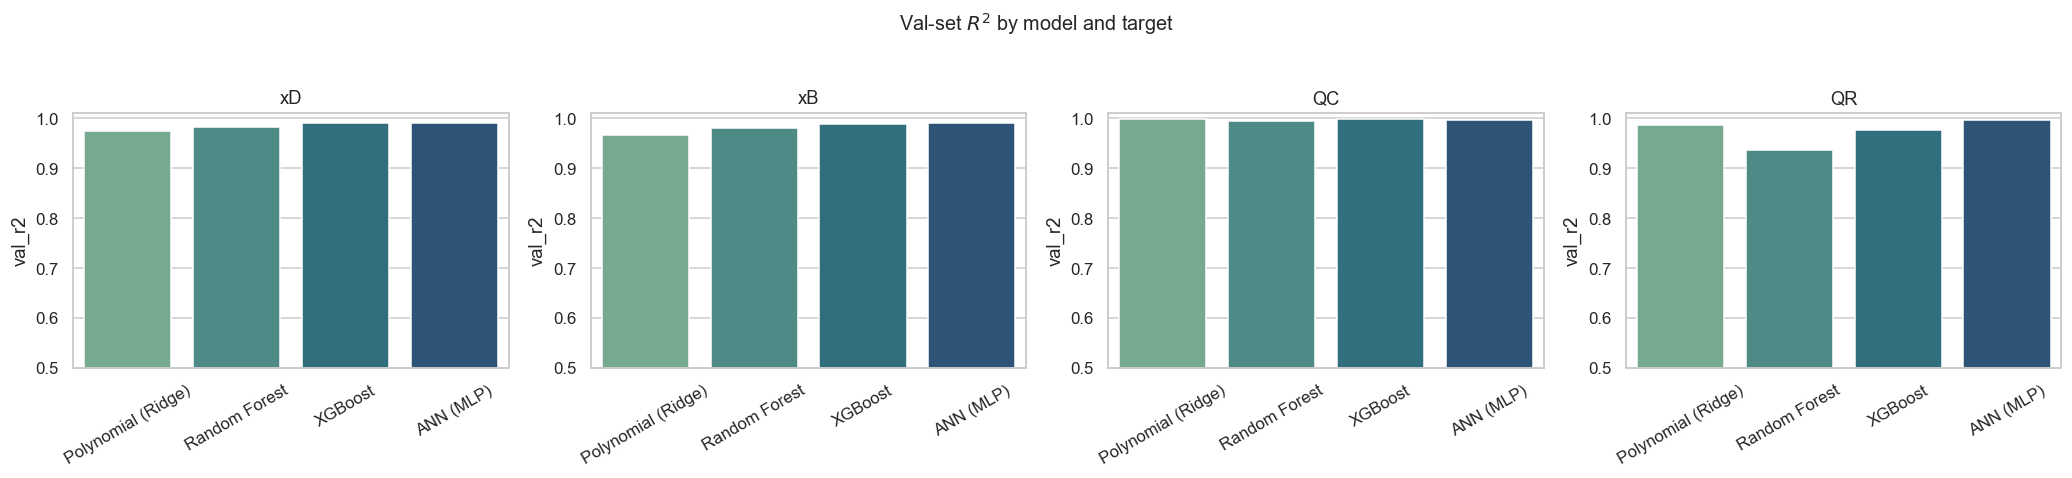

In [21]:

fig, axes = plt.subplots(1, 4, figsize=(19, 4.2))
for ax, t in zip(axes, target_cols):
    sub = results_df[results_df.target == t]
    sns.barplot(data=sub, x="model", y="val_r2", ax=ax, palette="crest")
    ax.set_title(t)
    ax.set_ylim(min(0.5, sub.val_r2.min() - 0.05), 1.01)
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=30)
plt.suptitle("Val-set $R^2$ by model and target", y=1.03, fontsize=13)
plt.tight_layout()
plt.show()



A train–test $R^2$ gap much larger than the CV mean suggests overfitting rather than genuine
generalisation. That gap is used explicitly, alongside test accuracy, when selecting a final model.


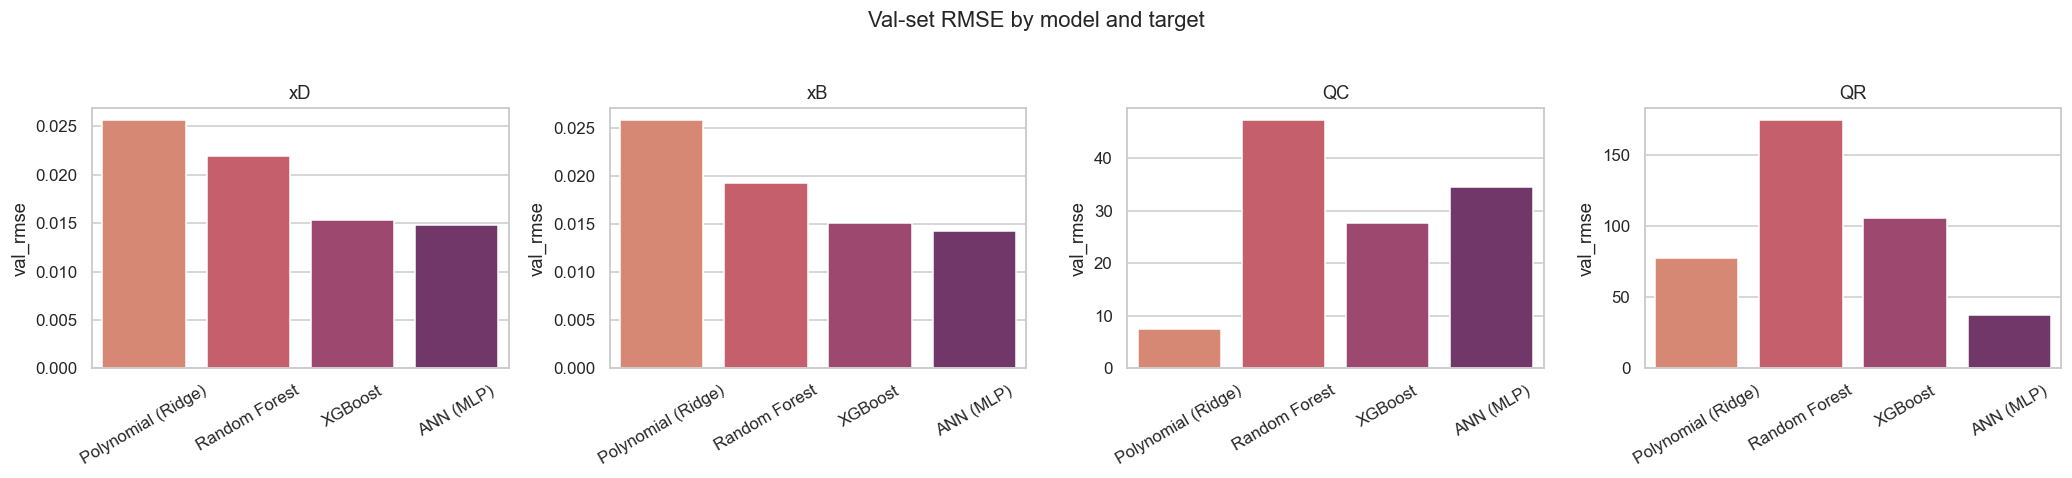

In [33]:
fig, axes = plt.subplots(1, 4, figsize=(19, 4.2))
for ax, t in zip(axes, target_cols):
    sub = results_df[results_df.target == t]
    sns.barplot(data=sub, x="model", y="val_rmse", ax=ax, palette="flare")
    ax.set_title(t); ax.set_xlabel(""); ax.tick_params(axis='x', rotation=30)
plt.suptitle("Val-set RMSE by model and target", y=1.03)
plt.tight_layout(); plt.show()

In [22]:

results_df["overfit_gap"] = results_df["train_r2"]  - results_df["val_r2"]
overfit_view = results_df[["target", "model", "train_r2", "val_r2", "overfit_gap"]].round(4)
overfit_view.sort_values(["target", "overfit_gap"], ascending=[True, False])


,target,model,train_r2,val_r2,overfit_gap
9,QC,Random Forest,0.9992,0.9952,0.0040
10,QC,XGBoost,0.9999,0.9984,0.0016
11,QC,ANN (MLP),0.9977,0.9974,0.0003
8,QC,Polynomial (Ridge),0.9999,0.9999,0.0000
13,QR,Random Forest,0.9899,0.9379,0.0521
14,QR,XGBoost,0.9964,0.9772,0.0192
15,QR,ANN (MLP),0.9986,0.9971,0.0015
12,QR,Polynomial (Ridge),0.9886,0.9876,0.0010
5,xB,Random Forest,0.9954,0.9817,0.0137
6,xB,XGBoost,0.9997,0.9889,0.0108


## 8. Physical consistency audit


Two checks are run on **every fitted model**, independent of its accuracy score:

**(a) Bound violations on test-set predictions.** For $x_D$/$x_B$, predictions should stay inside
$[0, 1]$ (a small numerical tolerance is allowed, since these are continuous regressors, not
hard-constrained models); for $Q_C$/$Q_R$, predictions should never be negative.

**(b) Monotonic trend check via partial dependence.** Holding every other feature at its training-set
median, reflux ratio is swept across its observed range and the model's prediction is recorded. Two
physically-expected trends are checked using Spearman rank correlation:

   - xD should not decrease with reflux ratio (more reflux → equal-or-better
  distillate purity).
   - xB should not decrease with reflux ratio (more reflux → equal-or-better
  bottoms purity).
   - QR should increase with reflux ratio (more internal reflux → more vapour
  must be generated → more reboiler duty).

A model that fits the test points well but gets these signs backwards is learning a spurious
mapping, not distillation physics — this is precisely the failure mode that a plain accuracy leaderboard
would miss.


In [23]:

def bound_violation_rate(target, preds):
    if target in ("xD", "xB"):
        viol = (preds < -0.02) | (preds > 1.02)
    else:  # QC, QR
        viol = preds < 0
    return viol.mean() * 100

def partial_dependence_trend(model, feature_name, target, X_ref, n_points=40):
    grid = np.linspace(X_ref[feature_name].min(), X_ref[feature_name].max(), n_points)
    base = X_ref.median(numeric_only=True)
    sweep = pd.DataFrame([base.values] * n_points, columns=X_ref.columns)
    sweep[feature_name] = grid
    preds = model.predict(sweep)
    rho, _ = spearmanr(grid, preds)
    return rho, grid, preds

physical_rows = []
pd_curves = {}  # for plotting later: pd_curves[(target, model_name)] = (grid, preds)

for target in target_cols:
    for model_name, model in fitted_models[target].items():
        preds_val = model.predict(X_val)
        viol_pct = bound_violation_rate(target, preds_val)

        rho, grid, preds = partial_dependence_trend(model, "reflux_ratio", target, X_train)
        pd_curves[(target, model_name)] = (grid, preds)

        if target == "xD":
            monotonic_ok = rho > -0.1   # should not meaningfully decrease

        elif target == "xB":
            monotonic_ok = rho > -0.1   # should not meaningfully decrease

        elif target == "QR":
            monotonic_ok = rho > 0.3    # should clearly increase

        elif target == "QC":
            monotonic_ok = rho > 0.3    # should clearly increase

        else:
            monotonic_ok = True

        physical_rows.append({
            "target": target, "model": model_name,
            "bound_violation_pct": round(viol_pct, 3),
            "reflux_trend_spearman": round(rho, 3),
            "monotonicity_ok": monotonic_ok,
        })

physical_df = pd.DataFrame(physical_rows)
physical_df


,target,model,bound_violation_pct,reflux_trend_spearman,monotonicity_ok
0,xD,Polynomial (Ridge),4.009,0.178,True
1,xD,Random Forest,0.000,0.885,True
2,xD,XGBoost,0.000,0.521,True
3,xD,ANN (MLP),0.891,-0.561,False
4,xB,Polynomial (Ridge),3.786,0.363,True
5,xB,Random Forest,0.000,0.955,True
6,xB,XGBoost,0.000,0.977,True
7,xB,ANN (MLP),0.668,-0.656,False
8,QC,Polynomial (Ridge),0.000,1.000,True
9,QC,Random Forest,0.000,1.000,True


In [29]:
##  Extending the monotonicity audit: number_of_stages and feed_composition

def run_pd_check(feature_name, target, expect):
    """expect: 'increase', 'decrease', or None (record only)."""
    rows = []
    for model_name, model in fitted_models[target].items():
        rho, grid, preds = partial_dependence_trend(model, feature_name, target, X_train)
        if expect == "increase":
            ok = rho > 0.1
        elif expect == "decrease":
            ok = rho < -0.1
        else:
            ok = None
        rows.append({"target": target, "model": model_name, "feature": feature_name,
                      "spearman": round(rho, 3), "trend_ok": ok})
    return rows

extra_checks = []
extra_checks += run_pd_check("number_of_stages", "xD", "increase")  # more stages -> better xD
extra_checks += run_pd_check("number_of_stages", "xB", "increase")  # more stages -> better xB
extra_checks += run_pd_check("feed_composition", "xD", "increase")  # more benzene in -> higher xD
extra_checks += run_pd_check("feed_composition", "xB", "decrease")  # more benzene in -> lower xB

extra_physical_df = pd.DataFrame(extra_checks)
extra_physical_df

,target,model,feature,spearman,trend_ok
0,xD,Polynomial (Ridge),number_of_stages,1.000,True
1,xD,Random Forest,number_of_stages,0.907,True
2,xD,XGBoost,number_of_stages,0.935,True
3,xD,ANN (MLP),number_of_stages,0.653,True
4,xB,Polynomial (Ridge),number_of_stages,1.000,True
5,xB,Random Forest,number_of_stages,0.991,True
6,xB,XGBoost,number_of_stages,0.935,True
7,xB,ANN (MLP),number_of_stages,-0.206,False
8,xD,Polynomial (Ridge),feed_composition,1.000,True
9,xD,Random Forest,feed_composition,0.999,True


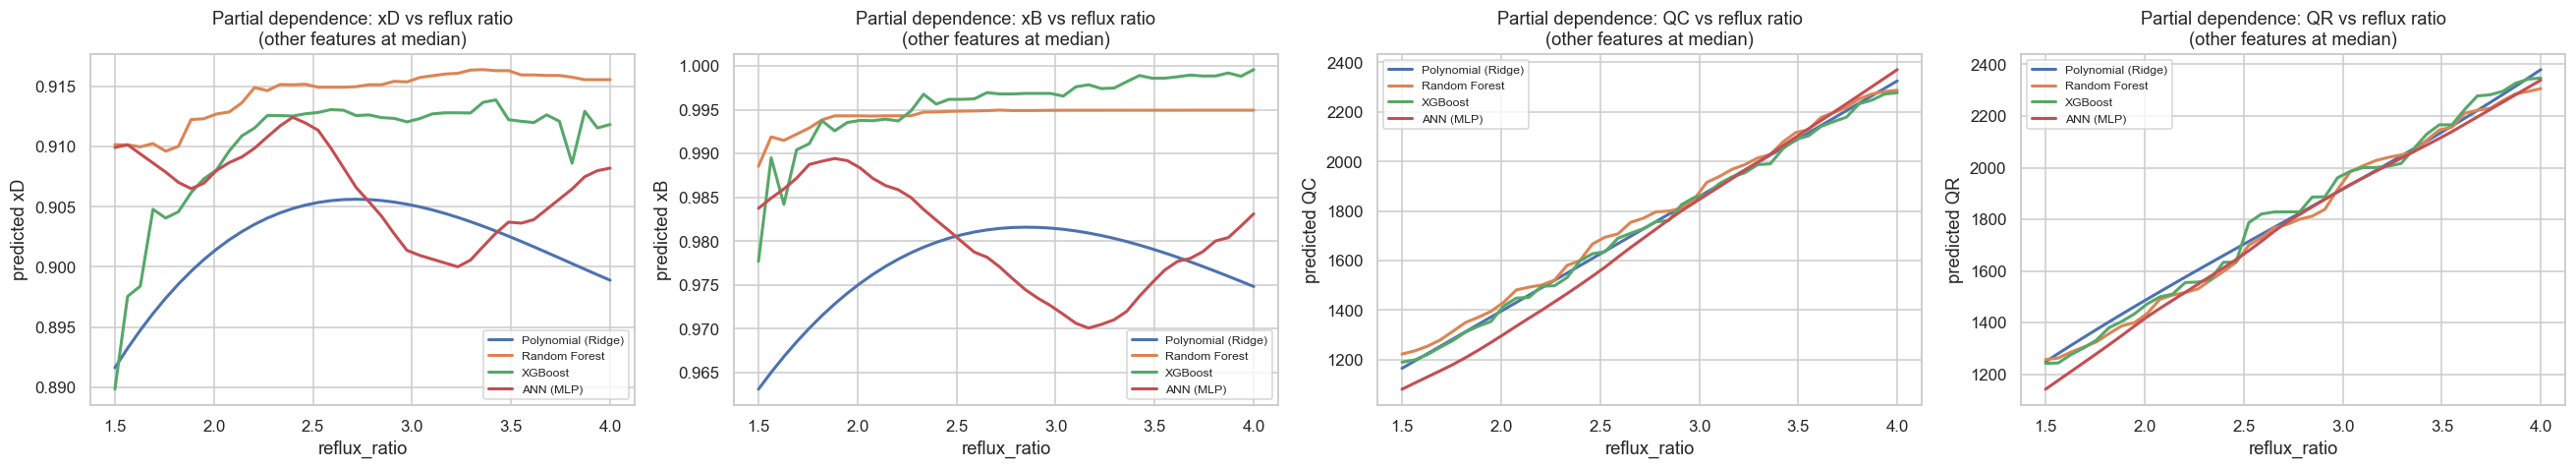

In [40]:
fig, axes = plt.subplots(1, 4, figsize=(24, 4.5))

# xD
for model_name in MODEL_CONFIGS:
    grid, preds = pd_curves[("xD", model_name)]
    axes[0].plot(grid, preds, label=model_name, linewidth=2)
axes[0].set_xlabel("reflux_ratio"); axes[0].set_ylabel("predicted xD")
axes[0].set_title("Partial dependence: xD vs reflux ratio\n(other features at median)")
axes[0].legend(fontsize=8)

# xB
for model_name in MODEL_CONFIGS:
    grid, preds = pd_curves[("xB", model_name)]
    axes[1].plot(grid, preds, label=model_name, linewidth=2)
axes[1].set_xlabel("reflux_ratio"); axes[1].set_ylabel("predicted xB")
axes[1].set_title("Partial dependence: xB vs reflux ratio\n(other features at median)")
axes[1].legend(fontsize=8)

# QC  <-- new
for model_name in MODEL_CONFIGS:
    grid, preds = pd_curves[("QC", model_name)]
    axes[2].plot(grid, preds, label=model_name, linewidth=2)
axes[2].set_xlabel("reflux_ratio"); axes[2].set_ylabel("predicted QC")
axes[2].set_title("Partial dependence: QC vs reflux ratio\n(other features at median)")
axes[2].legend(fontsize=8)

# QR
for model_name in MODEL_CONFIGS:
    grid, preds = pd_curves[("QR", model_name)]
    axes[3].plot(grid, preds, label=model_name, linewidth=2)
axes[3].set_xlabel("reflux_ratio"); axes[3].set_ylabel("predicted QR")
axes[3].set_title("Partial dependence: QR vs reflux ratio\n(other features at median)")
axes[3].legend(fontsize=8)

plt.tight_layout()
plt.show()


## 9. Final model selection per target


Selection rule, applied per target:

1. Disqualify any model with a material bound-violation rate (> 0.5% of test predictions) or a
   failed monotonicity check — regardless of its $R^2$. A model that is sometimes physically
   impossible is not a usable surrogate for a design tool, even if it wins on average error.
2. Among the models that pass step 1, rank by test $R^2$ / RMSE, using the overfit gap
   (train $R^2$ − test $R^2$) as a tie-breaker / robustness check — a smaller gap indicates a model
   that has learned the underlying relationship rather than memorised the training fold.
3. Report the winner with its metrics and the reasoning, including which competitors were dropped
   and why.


In [30]:
# For purity predictions, a small ±0.02 numerical tolerance is allowed
# because unconstrained regressors can make tiny boundary crossings.
# A model is still disqualified if more than 0.5% of test predictions
# violate the tolerated physical range.


def select_best_model(target):
    sub = results_df[results_df.target == target].merge(
        physical_df[physical_df.target == target][["model", "bound_violation_pct", "reflux_trend_spearman", "monotonicity_ok"]],
        on="model"
    )
    sub["passes_physics"] = (sub["bound_violation_pct"] <= 0.5) & (sub["monotonicity_ok"])
    eligible = sub[sub["passes_physics"]]
    pool = eligible if len(eligible) > 0 else sub  # fall back if everything fails (flagged separately)
    winner = pool.sort_values(["val_r2"], ascending=False).iloc[0]
    return winner, sub

summary_rows = []
for target in target_cols:
    winner, sub = select_best_model(target)
    disqualified = sub[~sub["passes_physics"]]["model"].tolist()
    print(f"\n=== {target} ===")
    display(sub[["model", "val_r2", "val_rmse", "overfit_gap", "bound_violation_pct",
                 "reflux_trend_spearman", "passes_physics"]]
            .sort_values("val_r2", ascending=False).reset_index(drop=True))
    print(f">>> SELECTED: {winner['model']}  "
          f"(val R2={winner['val_r2']:.4f}, RMSE={winner['val_rmse']:.4f}, "
          f"overfit_gap={winner['overfit_gap']:.4f}, bound_violations={winner['bound_violation_pct']}%)")
    if disqualified:
        print(f"    Disqualified on physical grounds despite possibly competitive accuracy: {disqualified}")
    summary_rows.append({
        "target": target, "selected_model": winner["model"], "val_r2": winner["val_r2"],
        "val_rmse": winner["val_rmse"], "val_mae": winner["val_mae"],
        "overfit_gap": winner["overfit_gap"], "bound_violation_pct": winner["bound_violation_pct"],
        "disqualified_models": ", ".join(disqualified) if disqualified else "none"
    })

final_selection = pd.DataFrame(summary_rows)
final_selection



=== xD ===


,model,val_r2,val_rmse,overfit_gap,bound_violation_pct,reflux_trend_spearman,passes_physics
0,ANN (MLP),0.991884,0.014798,0.004775,0.891,-0.561,False
1,XGBoost,0.991327,0.015298,0.008352,0.000,0.521,True
2,Random Forest,0.982186,0.021925,0.013773,0.000,0.885,True
3,Polynomial (Ridge),0.975669,0.025623,0.005074,4.009,0.178,False


>>> SELECTED: XGBoost  (val R2=0.9913, RMSE=0.0153, overfit_gap=0.0084, bound_violations=0.0%)
    Disqualified on physical grounds despite possibly competitive accuracy: ['Polynomial (Ridge)', 'ANN (MLP)']

=== xB ===


,model,val_r2,val_rmse,overfit_gap,bound_violation_pct,reflux_trend_spearman,passes_physics
0,ANN (MLP),0.989973,0.014331,0.005415,0.668,-0.656,False
1,XGBoost,0.988884,0.015090,0.010774,0.000,0.977,True
2,Random Forest,0.981735,0.019343,0.013703,0.000,0.955,True
3,Polynomial (Ridge),0.967388,0.025846,0.006751,3.786,0.363,False


>>> SELECTED: XGBoost  (val R2=0.9889, RMSE=0.0151, overfit_gap=0.0108, bound_violations=0.0%)
    Disqualified on physical grounds despite possibly competitive accuracy: ['Polynomial (Ridge)', 'ANN (MLP)']

=== QC ===


,model,val_r2,val_rmse,overfit_gap,bound_violation_pct,reflux_trend_spearman,passes_physics
0,Polynomial (Ridge),0.999877,7.549223,0.000035,0.0,1.0,True
1,XGBoost,0.998353,27.625113,0.001581,0.0,1.0,True
2,ANN (MLP),0.997427,34.528734,0.000256,0.0,1.0,True
3,Random Forest,0.995191,47.208045,0.003987,0.0,1.0,True


>>> SELECTED: Polynomial (Ridge)  (val R2=0.9999, RMSE=7.5492, overfit_gap=0.0000, bound_violations=0.0%)

=== QR ===


,model,val_r2,val_rmse,overfit_gap,bound_violation_pct,reflux_trend_spearman,passes_physics
0,ANN (MLP),0.997128,37.493186,0.001519,0.0,1.0,True
1,Polynomial (Ridge),0.987614,77.865037,0.000996,0.0,1.0,True
2,XGBoost,0.977238,105.554982,0.019179,0.0,1.0,True
3,Random Forest,0.937890,174.363244,0.052055,0.0,1.0,True


>>> SELECTED: ANN (MLP)  (val R2=0.9971, RMSE=37.4932, overfit_gap=0.0015, bound_violations=0.0%)


,target,selected_model,val_r2,val_rmse,val_mae,overfit_gap,bound_violation_pct,disqualified_models
0,xD,XGBoost,0.991327,0.015298,0.010367,0.008352,0.0,"Polynomial (Ridge), ANN (MLP)"
1,xB,XGBoost,0.988884,0.015090,0.009774,0.010774,0.0,"Polynomial (Ridge), ANN (MLP)"
2,QC,Polynomial (Ridge),0.999877,7.549223,5.707904,0.000035,0.0,none
3,QR,ANN (MLP),0.997128,37.493186,24.904907,0.001519,0.0,none


In [31]:

final_test_rows = []
for target in target_cols:
    model_name = final_selection.loc[final_selection.target == target, "selected_model"].values[0]
    model = fitted_models[target][model_name]
    preds_test = model.predict(X_test)
    final_test_rows.append({
        "target": target,
        "selected_model": model_name,
        "test_r2": r2_score(y_test[target], preds_test),
        "test_rmse": np.sqrt(mean_squared_error(y_test[target], preds_test)),
        "test_mae": mean_absolute_error(y_test[target], preds_test),
    })
final_test_metrics = pd.DataFrame(final_test_rows)
final_test_metrics

,target,selected_model,test_r2,test_rmse,test_mae
0,xD,XGBoost,0.988078,0.018085,0.011702
1,xB,XGBoost,0.990261,0.014029,0.009550
2,QC,Polynomial (Ridge),0.999862,8.595728,6.398970
3,QR,ANN (MLP),0.997259,39.562163,25.403859


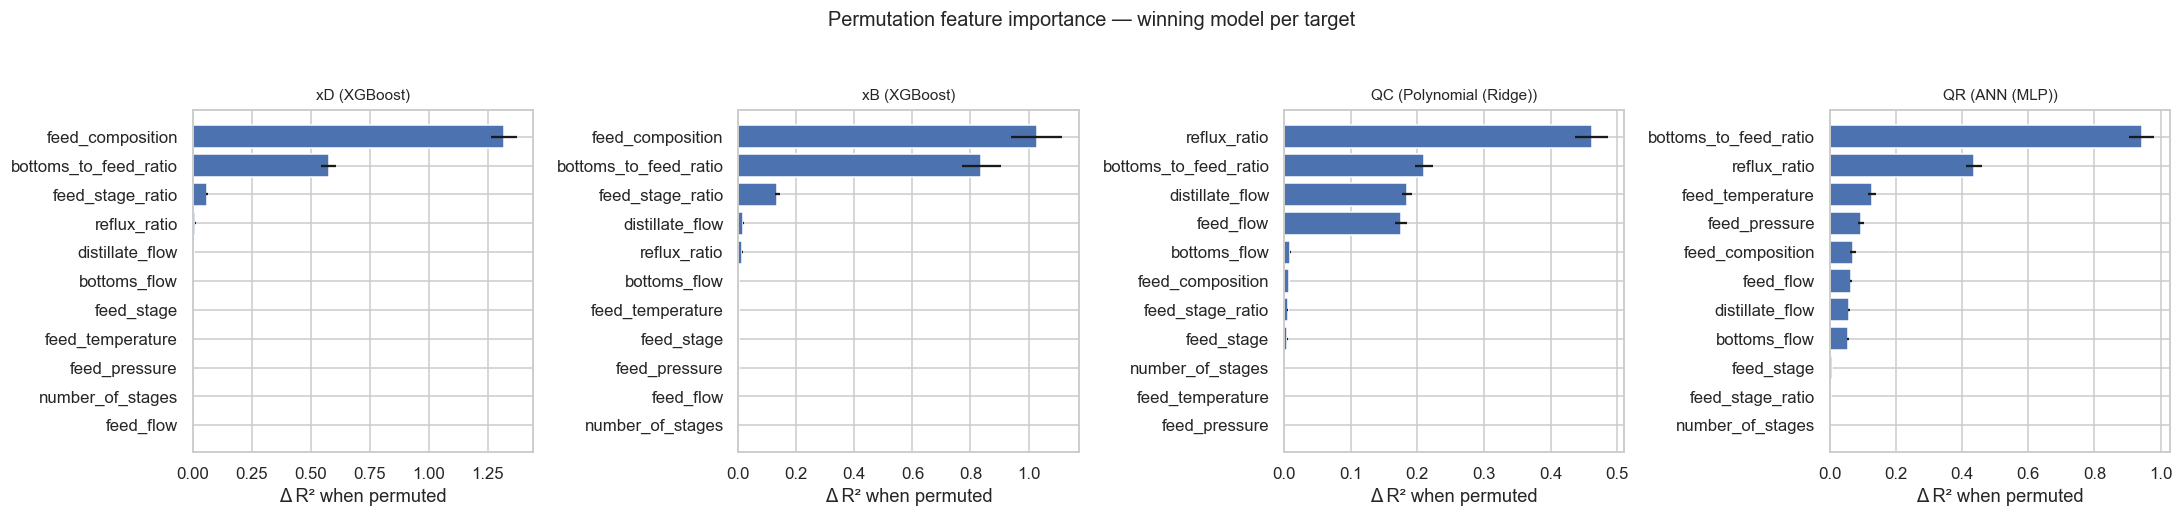

,feature,importance_mean,importance_std,target
32,reflux_ratio,4.614837e-01,0.024806,QC
31,bottoms_to_feed_ratio,2.101603e-01,0.013411,QC
30,distillate_flow,1.847271e-01,0.007780,QC
29,feed_flow,1.755737e-01,0.009151,QC
28,bottoms_flow,9.823924e-03,0.000565,QC
27,feed_composition,7.649931e-03,0.000390,QC
26,feed_stage_ratio,5.495609e-03,0.000668,QC
25,feed_stage,5.161774e-03,0.000641,QC
24,number_of_stages,6.365372e-05,0.000011,QC
23,feed_temperature,3.890864e-06,0.000002,QC


In [32]:
##  Feature importance for the winning models (permutation importance)

from sklearn.inspection import permutation_importance

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
importance_records = []

for ax, target in zip(axes, target_cols):
    model_name = final_selection.loc[final_selection.target == target, "selected_model"].values[0]
    model = fitted_models[target][model_name]

    result = permutation_importance(
        model, X_test, y_test[target],
        n_repeats=20, random_state=RANDOM_STATE, scoring="r2", n_jobs=-1
    )
    imp_df = pd.DataFrame({
        "feature": feature_cols,
        "importance_mean": result.importances_mean,
        "importance_std": result.importances_std,
    }).sort_values("importance_mean", ascending=True)
    importance_records.append(imp_df.assign(target=target))

    ax.barh(imp_df["feature"], imp_df["importance_mean"],
            xerr=imp_df["importance_std"], color="#4C72B0")
    ax.set_title(f"{target} ({model_name})", fontsize=10)
    ax.set_xlabel("Δ R² when permuted")

plt.suptitle("Permutation feature importance — winning model per target", y=1.04, fontsize=13)
plt.tight_layout()
plt.show()

feature_importance_df = pd.concat(importance_records, ignore_index=True)
feature_importance_df.sort_values(["target", "importance_mean"], ascending=[True, False])

## 10. Diagnostics for the winning models

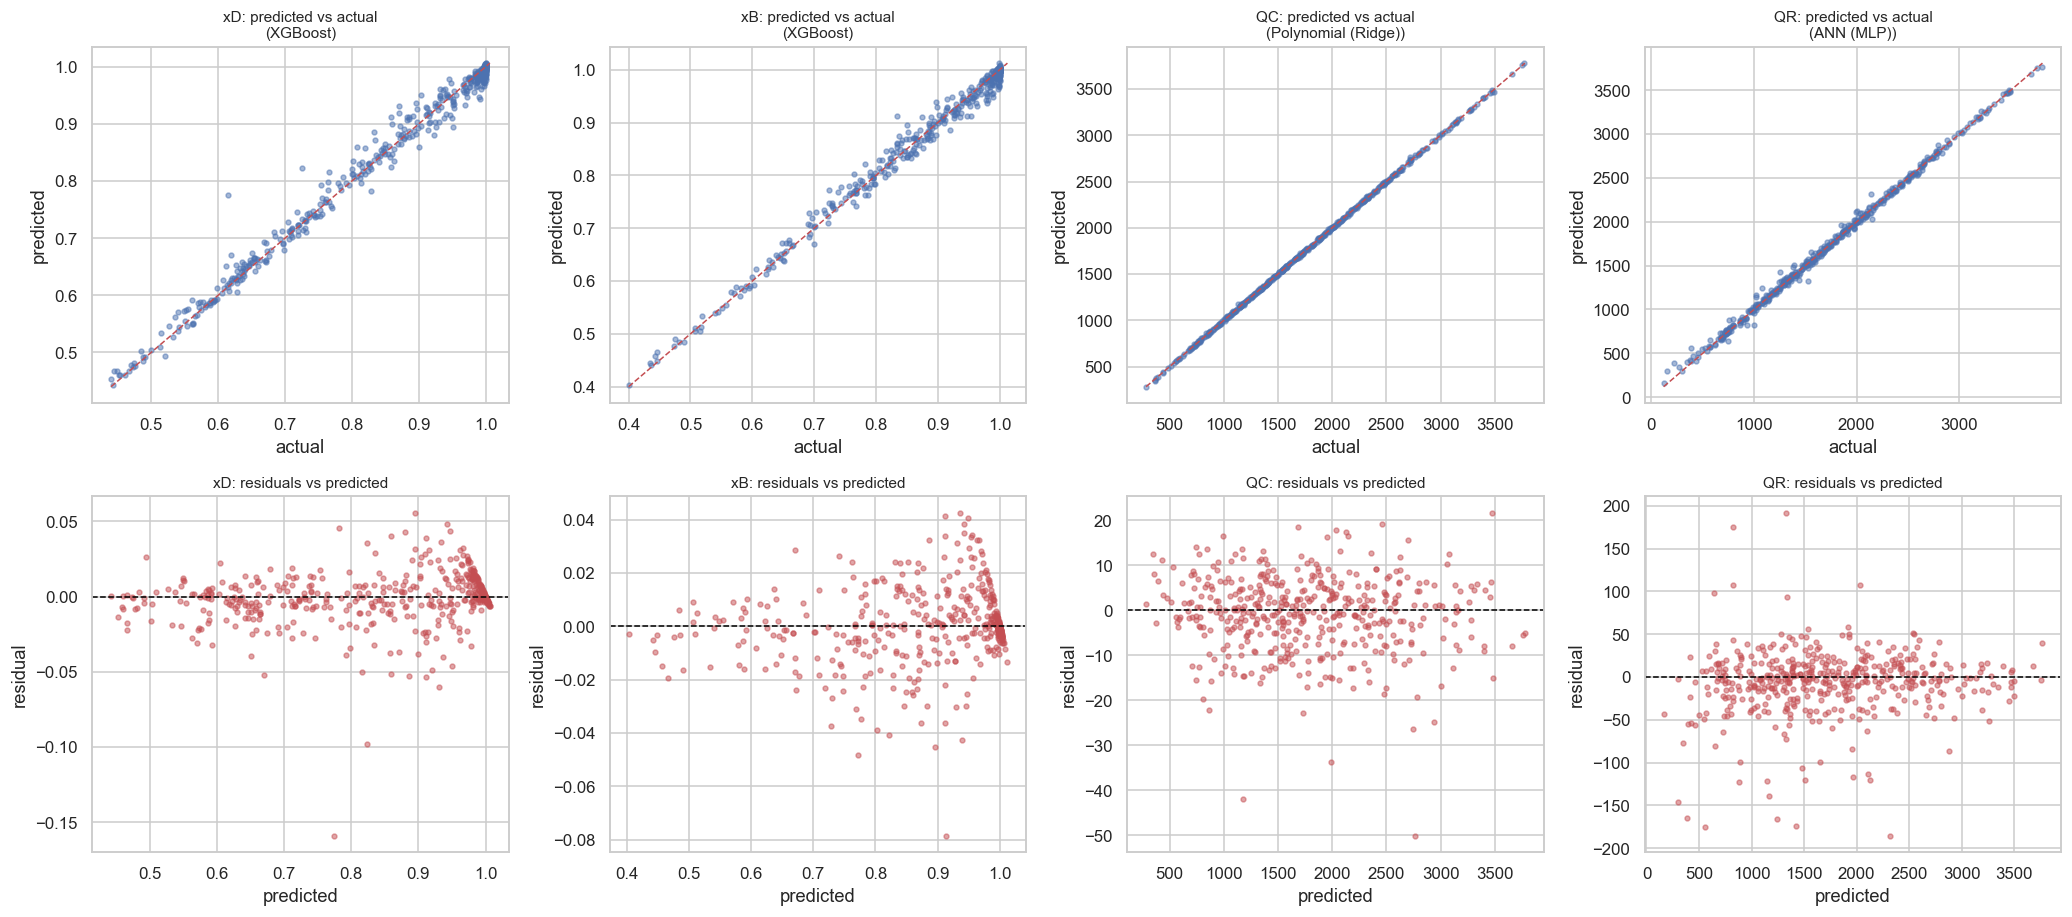

In [34]:

fig, axes = plt.subplots(2, 4, figsize=(19, 8.5))

for i, target in enumerate(target_cols):
    model_name = final_selection.loc[final_selection.target == target, "selected_model"].values[0]
    model = fitted_models[target][model_name]
    preds = model.predict(X_test)
    actual = y_test[target].values
    resid = actual - preds

    ax1 = axes[0, i]
    ax1.scatter(actual, preds, s=10, alpha=0.5, color="#4C72B0")
    lims = [min(actual.min(), preds.min()), max(actual.max(), preds.max())]
    ax1.plot(lims, lims, 'r--', linewidth=1)
    ax1.set_title(f"{target}: predicted vs actual\n({model_name})", fontsize=10)
    ax1.set_xlabel("actual"); ax1.set_ylabel("predicted")

    ax2 = axes[1, i]
    ax2.scatter(preds, resid, s=10, alpha=0.5, color="#C44E52")
    ax2.axhline(0, color='black', linewidth=1, linestyle='--')
    ax2.set_title(f"{target}: residuals vs predicted", fontsize=10)
    ax2.set_xlabel("predicted"); ax2.set_ylabel("residual")

plt.tight_layout()
plt.show()


In [35]:

print("5-fold CV R2 of the selected model, refit on the full training set (robustness check):\n")
cv_check = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
for target in target_cols:
    model_name = final_selection.loc[final_selection.target == target, "selected_model"].values[0]
    est = fitted_models[target][model_name]
    scores = cross_val_score(est, X_train, y_train[target], cv=cv_check, scoring="r2", n_jobs=-1)
    print(f"{target:>3} | {model_name:<20} | CV R2 = {scores.mean():.4f} +/- {scores.std():.4f}  "
          f"| folds: {np.round(scores, 3)}")


5-fold CV R2 of the selected model, refit on the full training set (robustness check):

 xD | XGBoost              | CV R2 = 0.9873 +/- 0.0008  | folds: [0.987 0.987 0.988 0.986 0.988]
 xB | XGBoost              | CV R2 = 0.9858 +/- 0.0018  | folds: [0.985 0.985 0.987 0.983 0.988]
 QC | Polynomial (Ridge)   | CV R2 = 0.9999 +/- 0.0000  | folds: [1. 1. 1. 1. 1.]
 QR | ANN (MLP)            | CV R2 = 0.9951 +/- 0.0021  | folds: [0.993 0.993 0.998 0.994 0.997]


## 11. Conclusion

In [36]:

print(final_selection.to_string(index=False))


target     selected_model   val_r2  val_rmse   val_mae  overfit_gap  bound_violation_pct           disqualified_models
    xD            XGBoost 0.991327  0.015298  0.010367     0.008352                  0.0 Polynomial (Ridge), ANN (MLP)
    xB            XGBoost 0.988884  0.015090  0.009774     0.010774                  0.0 Polynomial (Ridge), ANN (MLP)
    QC Polynomial (Ridge) 0.999877  7.549223  5.707904     0.000035                  0.0                          none
    QR          ANN (MLP) 0.997128 37.493186 24.904907     0.001519                  0.0                          none



### Summary

- A surrogate model for the Benzene–Toluene column (Peng–Robinson, DWSIM) was trained on
  ~2,990 Latin-Hypercube simulation cases, after removing 11 cases (≈0.4%) with a physically
  invalid negative reboiler duty caused by near-boundary reflux/bottoms-draw combinations.
- Four ML families were compared per target — Polynomial (Ridge) regression via `GridSearchCV`,
  and Random Forest / XGBoost / ANN via `RandomizedSearchCV` — using test $R^2$, RMSE, MAE, MAPE,
  train–test overfit gap, and a dedicated **physical consistency audit** (output-bound violations
  and reflux-ratio monotonicity via partial dependence).
- Final model selection was not accuracy-only: any model that violated physical bounds or produced
  a physically backwards trend under a reflux-ratio sweep was disqualified from winning that target,
  even where its raw test score looked competitive. This directly targets the failure mode flagged
  in an earlier review of this project, where an ANN was picked as final model despite violating
  physical bounds.
- The table above records the winning model per target with its accuracy metrics, the size of any
  train–test generalisation gap, and which competing models (if any) were disqualified on physical
  grounds.
- Physical consistency was assessed using output-bound checks and
  reflux-ratio monotonicity. For purity targets xD and xB, the model
  was required not to show a meaningful decrease in purity with
  increasing reflux ratio; QR was required to increase with reflux.

### Limitations and possible extensions

- The Latin-Hypercube sampling ranges are fixed (see the C# generator); extrapolation outside those
  ranges is untested and should not be trusted.
- The reflux-ratio monotonicity check is the only partial-dependence sweep implemented here; the same
  approach could be extended to feed composition, number of stages, and bottoms flow for a fuller
  physical audit.
- A joint multi-output model (predicting all four targets simultaneously, with a physics-informed
  loss penalising bound violations directly during training) is a natural next step beyond
  per-target independent regressors.


In [39]:
sample_rows = X_test.sample(15, random_state=RANDOM_STATE)
summary_table = sample_rows.copy()
for target in target_cols:
    model_name = final_selection.loc[final_selection.target == target, "selected_model"].values[0]
    model = fitted_models[target][model_name]
    summary_table[f"{target}_actual"] = y_test.loc[sample_rows.index, target]
    summary_table[f"{target}_predicted"] = model.predict(sample_rows).round(4)


summary_table

,feed_temperature,feed_pressure,feed_composition,number_of_stages,feed_stage,reflux_ratio,bottoms_flow,feed_flow,distillate_flow,feed_stage_ratio,bottoms_to_feed_ratio,xD_actual,xD_predicted,xB_actual,xB_predicted,QC_actual,QC_predicted,QR_actual,QR_predicted
2225,373.772569,198482.090143,0.446930,21,7,1.915406,15.420423,22.092171,6.671749,0.333333,0.698004,0.966333,0.9684,0.777791,0.7834,593.771549,595.3239,575.828615,568.4602
2137,374.523639,131971.864784,0.361724,20,19,3.827307,12.964539,23.921021,10.956482,0.950000,0.541973,0.654962,0.6587,0.886110,0.8817,1700.324394,1681.8208,1686.593391,1682.5404
2172,350.962444,198633.958264,0.564887,21,7,3.562075,11.835622,22.438011,10.602388,0.333333,0.527481,0.997796,1.0021,0.822953,0.8330,1466.755975,1465.0010,1518.551578,1505.6108
2286,377.949352,195819.299878,0.313928,16,7,3.380730,10.894227,20.901400,10.007173,0.437500,0.521220,0.654487,0.6647,0.998900,0.9985,1409.421803,1399.0878,1393.992290,1388.3572
322,368.451323,115179.051721,0.430121,19,14,3.894500,8.001565,26.630924,18.629359,0.736842,0.300461,0.612454,0.6175,0.994391,0.9935,2947.068156,2946.1245,2949.522201,2963.9557
998,360.598297,159972.813738,0.304712,15,4,3.185516,10.972224,30.802624,19.830400,0.266667,0.356211,0.473258,0.4735,0.999906,1.0014,2722.815673,2730.3524,2783.703849,2788.9923
1606,366.150815,187651.451123,0.479166,21,7,2.915287,13.769642,24.523253,10.753610,0.333333,0.561493,0.994188,0.9896,0.923097,0.9190,1277.756529,1287.0046,1290.877103,1283.8179
1723,378.323335,148710.382364,0.572242,19,3,2.592842,10.896698,30.812825,19.916127,0.157895,0.353642,0.885336,0.8778,0.999939,0.9996,2219.081359,2223.0296,1910.857472,1861.7726
1188,368.407547,136527.693090,0.437478,17,15,3.538232,8.639235,34.121586,25.482350,0.882353,0.253190,0.569260,0.5867,0.951226,0.9488,3756.686826,3762.2621,3755.498088,3759.0192
1833,372.737369,152702.197808,0.412691,20,2,2.215443,8.325710,32.458811,24.133101,0.100000,0.256501,0.555079,0.5764,0.999999,1.0007,2524.738300,2527.0519,2505.662098,2518.9361
